# VGAE Embeddings for Contig Binning

A variational graph autoencoder learns probabilistic contig embeddings by reconstructing assembly-graph edges from adjacency/TNF/coverage features, with marker cannot-link regularization.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'VGAE'

class VGAEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, dropout=0.25):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.mu = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.logstd = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.dropout = dropout

    def forward(self, x, adjacency):
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        h = F.relu(a_hat @ self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return a_hat @ self.mu(h), torch.clamp(a_hat @ self.logstd(h), -4, 4)

def train_vgae(seed, epochs=300, patience=35, lr=0.01, constraint_weight=0.25):
    set_seed(seed)
    x = torch.tensor(features, dtype=torch.float32)
    adj = torch.tensor(adjacency, dtype=torch.float32)
    target = torch.maximum(adj, torch.eye(adj.shape[0]))
    pos_weight = (target.numel() - target.sum()) / target.sum().clamp_min(1.0)
    pairs = torch.tensor(marker_pairs, dtype=torch.long) if len(marker_pairs) else None
    model = VGAEEncoder(features.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    best_state, best_loss, wait = None, float('inf'), 0
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        mu, logstd = model(x, adj)
        z = mu + torch.randn_like(mu) * torch.exp(logstd)
        logits = z @ z.T
        recon = F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight)
        kl = -0.5 / x.shape[0] * torch.mean(torch.sum(1 + 2 * logstd - mu.pow(2) - torch.exp(2 * logstd), dim=1))
        loss = recon + 0.01 * kl
        if pairs is not None:
            loss = loss + constraint_weight * torch.exp(-F.pairwise_distance(mu[pairs[:, 0]], mu[pairs[:, 1]], p=2)).mean()
        loss.backward()
        opt.step()
        current = float(loss.item())
        if current < best_loss - 1e-5:
            best_loss = current
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        mu, _ = model(x, adj)
        embeddings = F.normalize(mu, p=2, dim=1).cpu().numpy()
    return embeddings, {'epoch': epoch, 'loss': best_loss}

def run_once(seed):
    embeddings, history = train_vgae(seed)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics.update({'epochs': history['epoch'], 'loss': history['loss']})
    return metrics


run 01 seed=7: precision=0.8821, recall=0.7328, f1=0.8006, ari=0.5891, nmi=0.7350
run 02 seed=8: precision=0.8684, recall=0.7328, f1=0.7949, ari=0.5717, nmi=0.7115
run 03 seed=9: precision=0.8428, recall=0.7230, f1=0.7783, ari=0.4855, nmi=0.6559
run 04 seed=10: precision=0.8880, recall=0.7348, f1=0.8042, ari=0.5925, nmi=0.7368
run 05 seed=11: precision=0.8703, recall=0.7917, f1=0.8292, ari=0.6671, nmi=0.7785
run 06 seed=12: precision=0.8723, recall=0.7308, f1=0.7953, ari=0.5859, nmi=0.7370
run 07 seed=13: precision=0.8428, recall=0.6955, f1=0.7621, ari=0.5027, nmi=0.6684
run 08 seed=14: precision=0.8723, recall=0.7328, f1=0.7965, ari=0.5833, nmi=0.7270
run 09 seed=15: precision=0.8802, recall=0.7289, f1=0.7974, ari=0.5881, nmi=0.7375
run 10 seed=16: precision=0.8762, recall=0.7308, f1=0.7970, ari=0.5885, nmi=0.7388


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.882122,0.732809,0.800563,0.589110,0.735006,5,5,0.728076,285,0.813243
1,2,8,0.868369,0.732809,0.794851,0.571678,0.711518,5,5,0.729151,300,0.809237
2,3,9,0.842829,0.722986,0.778321,0.485547,0.655860,5,5,0.643501,189,0.820166
3,4,10,0.888016,0.734774,0.804160,0.592534,0.736768,5,5,0.735893,215,0.814867
4,5,11,0.870334,0.791749,0.829183,0.667112,0.778457,5,5,0.759506,300,0.810438
5,6,12,0.872299,0.730845,0.795331,0.585922,0.736981,5,5,0.728977,300,0.808087
6,7,13,0.842829,0.695481,0.762098,0.502700,0.668392,5,5,0.692050,218,0.818113
7,8,14,0.872299,0.732809,0.796493,0.583267,0.726999,5,5,0.729729,300,0.810949
8,9,15,0.880157,0.728880,0.797407,0.588095,0.737499,5,5,0.730559,300,0.810537
9,10,16,0.876228,0.730845,0.796960,0.588511,0.738806,5,5,0.730130,300,0.813212


,min,max,mean,std
precision,0.842829,0.888016,0.869548,0.015280
recall,0.695481,0.791749,0.733399,0.023540
f1,0.762098,0.829183,0.795537,0.017170
ari,0.485547,0.667112,0.575448,0.050300
nmi,0.655860,0.778457,0.722629,0.036057
aligned_macro_f1,0.643501,0.759506,0.720757,0.031586


<Axes: title={'center': 'VGAE: mean metrics over 10 runs'}, ylabel='score'>

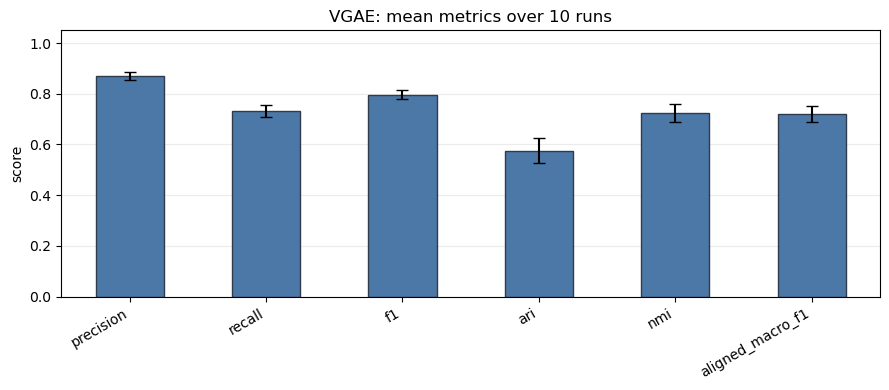

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.8821218074656189, 'recall': 0.7328094302554028, 'f1': 0.800563100206024, 'ari': 0.589109570251966, 'nmi': 0.735005672465647, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.7280755637295171, 'epochs': 285, 'loss': 0.8132322430610657}
VGAE: assembly graph coloured by predicted bin
bin 0: 71 contigs
bin 1: 70 contigs
bin 2: 115 contigs
bin 3: 157 contigs
bin 4: 96 contigs


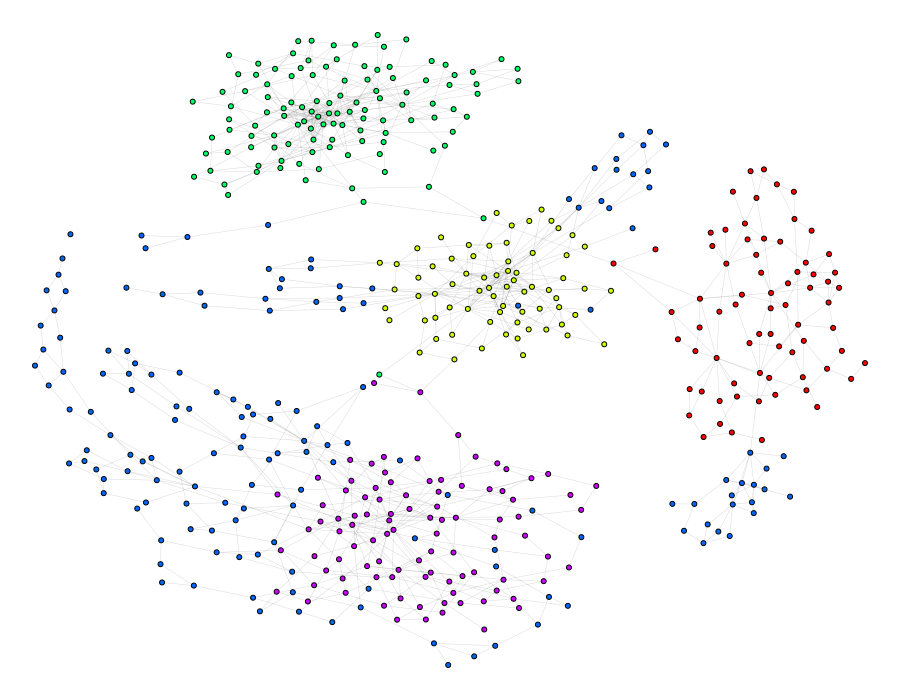

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.882122,0.732809,0.800563,0.589110,0.735006,5,5,0.728076,285,0.813243
1,original assembly graph,2,8,0.868369,0.732809,0.794851,0.572698,0.708180,5,5,0.728090,300,0.809305
2,original assembly graph,3,9,0.838900,0.687623,0.755766,0.500175,0.659869,5,5,0.694683,189,0.820141
3,original assembly graph,4,10,0.888016,0.734774,0.804160,0.592534,0.736768,5,5,0.735893,215,0.814867
4,original assembly graph,5,11,0.870334,0.791749,0.829183,0.667112,0.778457,5,5,0.759506,300,0.810452
5,original assembly graph,6,12,0.872299,0.730845,0.795331,0.585922,0.736981,5,5,0.728977,300,0.808054
6,original assembly graph,7,13,0.842829,0.695481,0.762098,0.502700,0.668392,5,5,0.692050,218,0.818113
7,original assembly graph,8,14,0.872299,0.732809,0.796493,0.583267,0.726999,5,5,0.729729,300,0.810949
8,original assembly graph,9,15,0.880157,0.728880,0.797407,0.588095,0.737499,5,5,0.730559,300,0.810537
9,original assembly graph,10,16,0.862475,0.715128,0.781920,0.566638,0.725768,5,5,0.717512,300,0.813247


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.838900  0.888016  0.867780  0.015989   
random edge removal              0.754420  0.854617  0.812574  0.030691   
random edge addition             0.750491  0.874263  0.832417  0.040018   
coverage-similarity edges added  0.811395  0.850688  0.833988  0.010071   
short contigs removed            0.848889  0.900000  0.863111  0.015332   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.687623  0.791749  0.728291  0.027970   
random edge removal              0.642436  0.809430  0.730845  0.057279   
random edge addition             0.630648  0.781925  0.724165  0.042047   
coverage-similarity edges added  0.703340  0.791749  0.757171  0.033702   
short contigs removed            0.715556  0.773333  0.750444  0.020341   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.755766  0.829183  ...  0.574825  0.047436   
random edge removal              0.708572  0.821982  ...  0.534904  0.088324   
random edge addition             0.685370  0.821115  ...  0.530012  0.058660   
coverage-similarity edges added  0.764344  0.820161  ...  0.566625  0.042895   
short contigs removed            0.779318  0.830585  ...  0.582096  0.026706   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.659869  0.778457  0.721392  0.034960   
random edge removal              0.598645  0.714398  0.657472  0.043425   
random edge addition             0.541877  0.696360  0.635008  0.050633   
coverage-similarity edges added  0.567343  0.627394  0.595248  0.020456   
short contigs removed            0.689723  0.757329  0.726813  0.019211   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.692050  0.759506  0.724508  0.019596  
random edge removal                     0.645967  0.769581  0.706321  0.041744  
random edge addition                    0.610009  0.751214  0.681275  0.044060  
coverage-similarity edges added         0.631395  0.720135  0.670066  0.034100  
short contigs removed                   0.658298  0.742385  0.696616  0.033429  

[5 rows x 24 columns]

<Axes: title={'center': 'VGAE: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

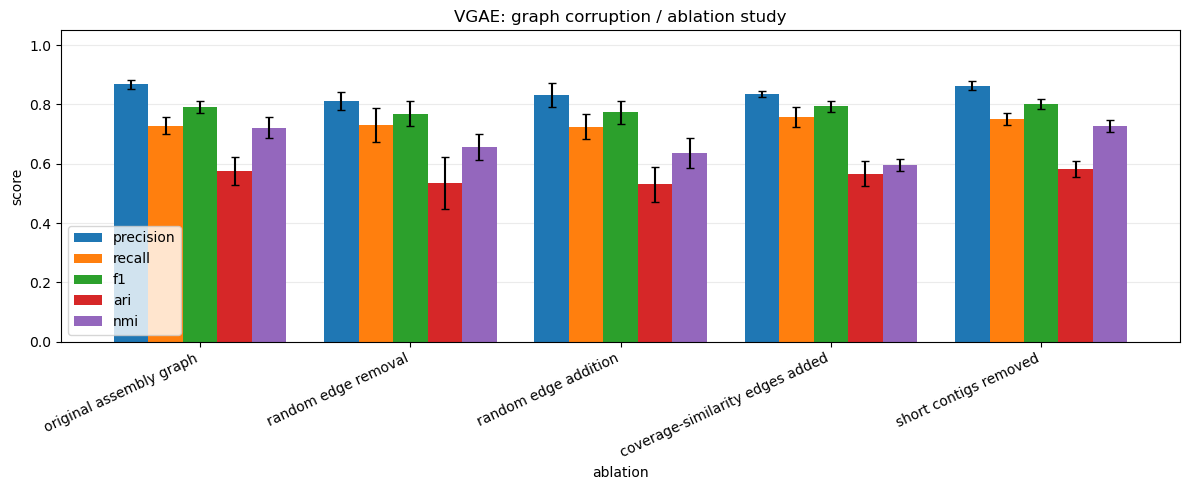

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
